In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
data_train_path = "Satellite_Image_Data_Split/train"
data_test_path = "Satellite_Image_Data_Split/test"
data_val_path = "Satellite_Image_Data_Split/valid"

In [3]:
img_width = 180
img_height = 180

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 3924 files belonging to 4 classes.


In [5]:
data_cat = data_train.class_names

In [6]:
data_train.class_names

['cloudy', 'desert', 'green_area', 'water']

In [18]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 838 files belonging to 4 classes.


In [19]:
data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 839 files belonging to 4 classes.


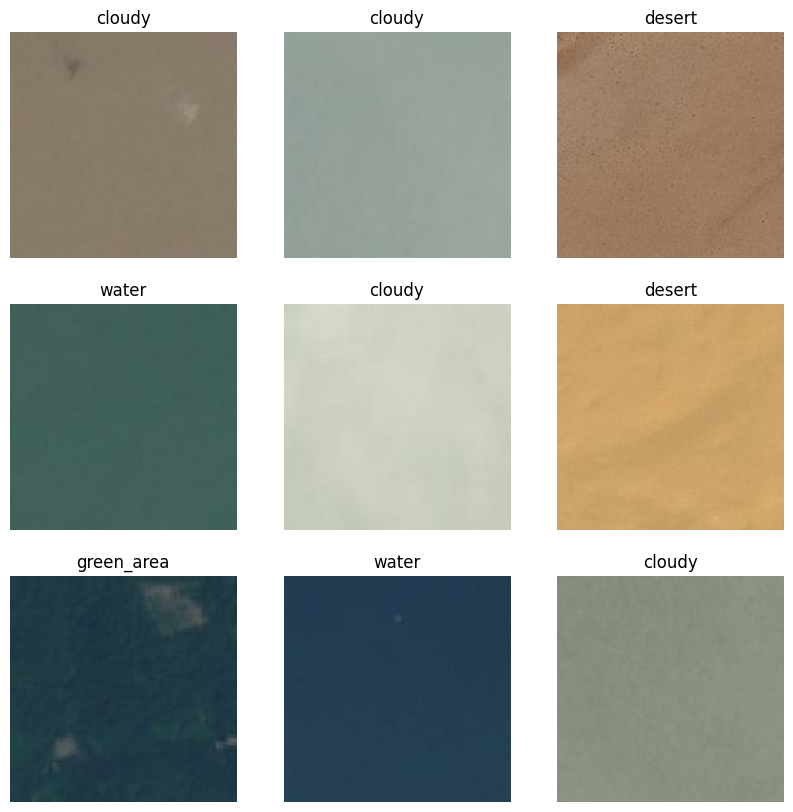

In [20]:
plt.figure(figsize=(10, 10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [21]:
from tensorflow.keras.models import Sequential

In [22]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [24]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
])

In [26]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [27]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 68s 521ms/step - accuracy: 0.6643 - loss: 0.9599 - val_accuracy: 0.8141 - val_loss: 0.3759
Epoch 2/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 44s 360ms/step - accuracy: 0.8449 - loss: 0.3531 - val_accuracy: 0.8749 - val_loss: 0.2885
Epoch 3/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 50s 407ms/step - accuracy: 0.8603 - loss: 0.3038 - val_accuracy: 0.8176 - val_loss: 0.3684
Epoch 4/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 55s 448ms/step - accuracy: 0.8617 - loss: 0.3172 - val_accuracy: 0.7986 - val_loss: 0.3755
Epoch 5/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 58s 472ms/step - accuracy: 0.8655 - loss: 0.3001 - val_accuracy: 0.8546 - val_loss: 0.3081
Epoch 6/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 43s 352ms/step - accuracy: 0.8810 - loss: 0.2584 - val_accuracy: 0.9082 - val_loss: 0.2385
Epoch 7/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 41s 334ms/step - accuracy: 0.8889 - loss: 0.2482 - val_accuracy: 0.8760 - val_loss: 0.2540
Epoch 8/25
123/123 ━━━━━━━━━━━━━━━━━━━━ 41s 332ms/step - accuracy: 0.8882 - loss: 0

Text(0.5, 1.0, 'Loss')

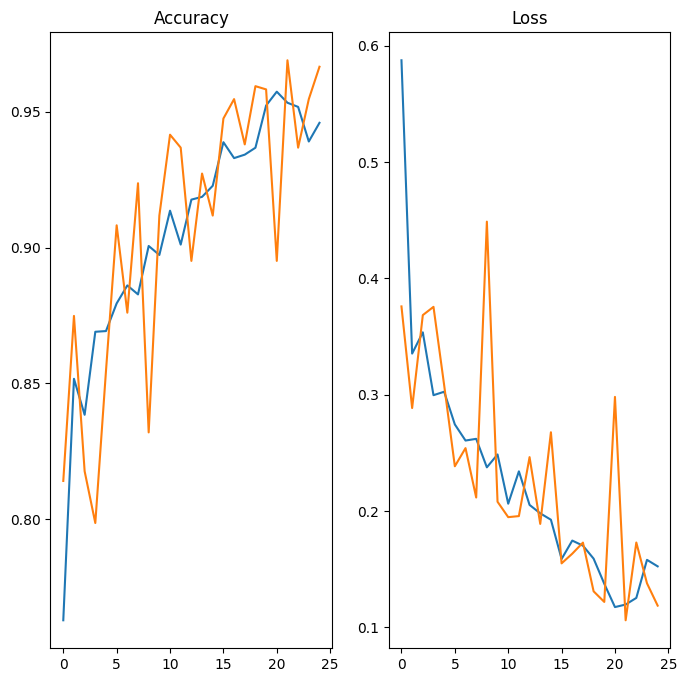

In [28]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.title('Loss')

In [29]:
loss, accuracy = model.evaluate(data_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.9578 - loss: 0.1338
Test Accuracy: 96.30%


In [31]:
model.save('Satellite_Image_Classify.keras')